# Midterm Project: Image Classification with Machine Learning Pipeline
**Nama:** Mirna Rahmania Melba

**Dataset:** EMNIST Letters (CSV format)

**Pipeline:** Dataset Preparation → HOG Feature Extraction → SVM Classification → Evaluation

In [1]:
!pip install numpy matplotlib seaborn scikit-image scikit-learn pandas -q

---
## 1. Dataset Preparation
Load EMNIST Letters dari CSV, pilih 100 sampel per kelas (26 kelas = 2600 total), shuffle, lalu split 80/20.

In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# ── Load CSV dataset ──────────────────────────────────────────────────────────
# Format: kolom pertama = label (1-26), kolom 1-784 = nilai pixel
df = pd.read_csv('emnist-letters-train.csv', header=None)

print(f"Shape dataset : {df.shape}")
print(f"Label range   : {df[0].min()} - {df[0].max()}")
print(f"Jumlah kelas  : {df[0].nunique()}")

# Pisahkan label dan pixel
data_labels = df[0].values - 1           # normalisasi ke 0-25
data_images = df.iloc[:, 1:].values      # (N, 784)

print(f"\ndata_images shape : {data_images.shape}")
print(f"data_labels shape : {data_labels.shape}")

Shape dataset : (6515, 785)
Label range   : 1 - 26
Jumlah kelas  : 26

data_images shape : (6515, 784)
data_labels shape : (6515,)


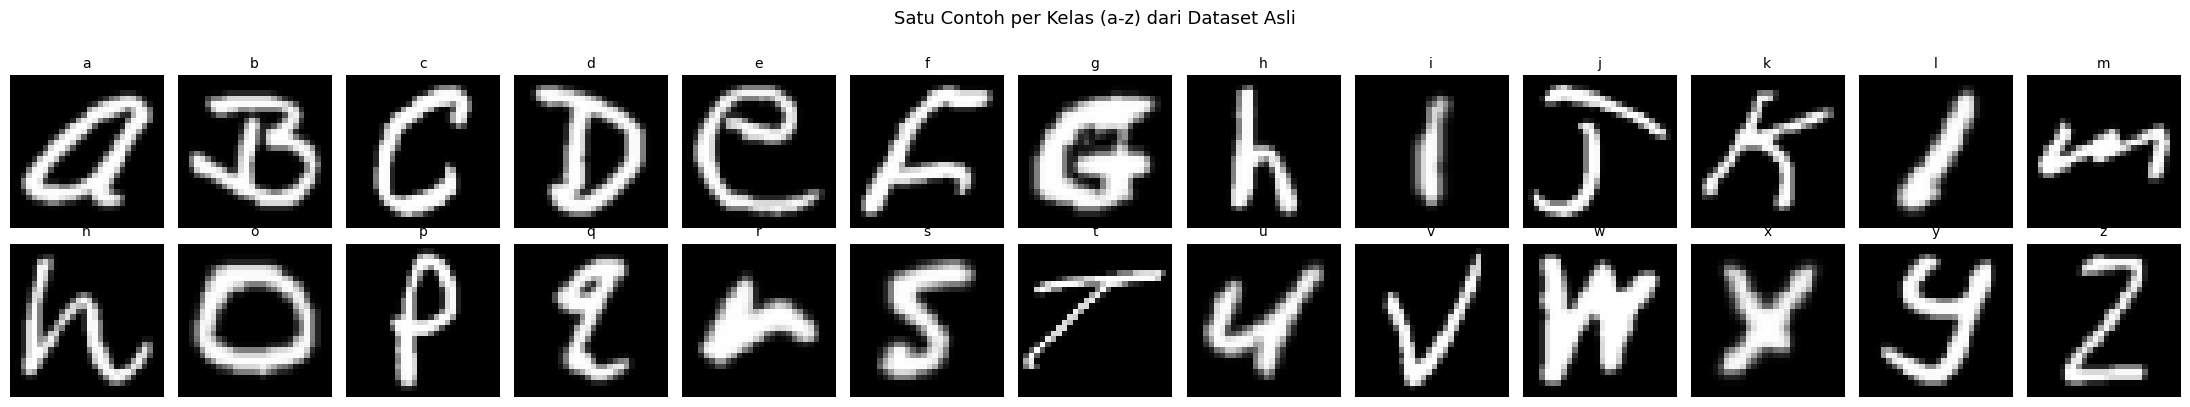

In [4]:
# ── Visualisasi satu contoh per kelas dari dataset asli ──────────────────────
fig, axes = plt.subplots(2, 13, figsize=(22, 4))
axes = axes.flatten()

for class_idx in range(26):
    idx = np.where(data_labels == class_idx)[0][0]
    img = data_images[idx].reshape(28, 28).T    # EMNIST perlu di-transpose
    axes[class_idx].imshow(img, cmap='gray')
    axes[class_idx].set_title(chr(class_idx + 97), fontsize=10)
    axes[class_idx].axis('off')

plt.suptitle("Satu Contoh per Kelas (a-z) dari Dataset Asli", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ── Pilih 100 sampel per kelas -> 2600 total, lalu shuffle ───────────────────
NUM_CLASSES   = 26
SAMPLES_CLASS = 100

selected_images = []
selected_labels = []

for class_idx in range(NUM_CLASSES):
    idx = np.where(data_labels == class_idx)[0]
    chosen = np.random.choice(idx, SAMPLES_CLASS, replace=False)
    selected_images.append(data_images[chosen])
    selected_labels.append(data_labels[chosen])

X_all = np.vstack(selected_images)   # (2600, 784)
y_all = np.hstack(selected_labels)   # (2600,)

# Shuffle sebelum diproses lebih lanjut
shuffle_idx = np.random.permutation(len(X_all))
X_all = X_all[shuffle_idx]
y_all = y_all[shuffle_idx]

print(f"Total setelah seleksi : {len(X_all)} sampel")
print(f"Distribusi kelas (5 pertama): {dict(list(zip(*np.unique(y_all, return_counts=True)))[:5])} ...")

Total setelah seleksi : 2600 sampel
Distribusi kelas (5 pertama): {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100)} ...


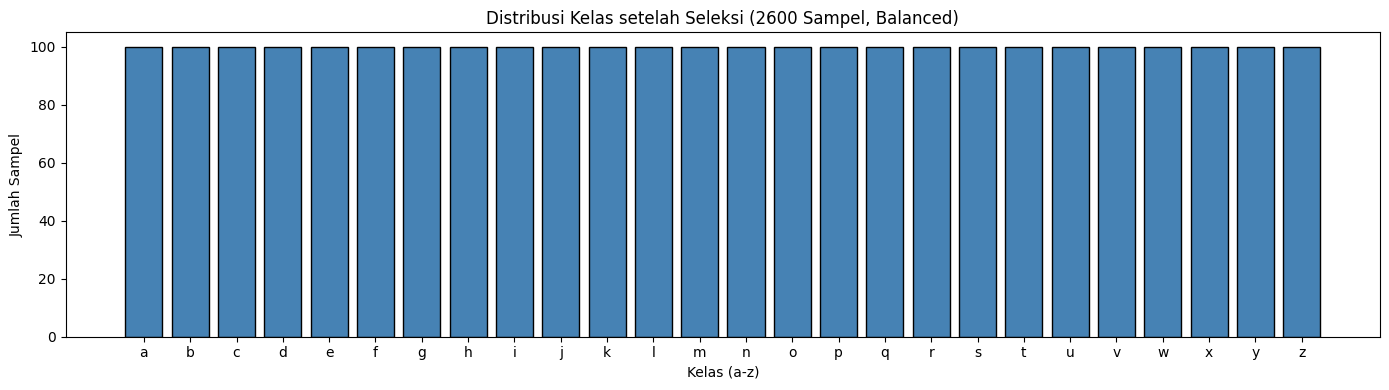

In [6]:
# ── Bar chart distribusi kelas ────────────────────────────────────────────────
classes, counts = np.unique(y_all, return_counts=True)
plt.figure(figsize=(14, 4))
plt.bar([chr(c + 97) for c in classes], counts, color='steelblue', edgecolor='black')
plt.xlabel('Kelas (a-z)')
plt.ylabel('Jumlah Sampel')
plt.title('Distribusi Kelas setelah Seleksi (2600 Sampel, Balanced)')
plt.tight_layout()
plt.show()

In [7]:
# ── Split 80% train / 20% test (stratified) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (2080, 784)  |  y_train : (2080,)
X_test  : (520, 784)   |  y_test  : (520,)


---
## 2. Feature Extraction - HOG
Histogram of Oriented Gradients dengan parameter yang diubah dari default.

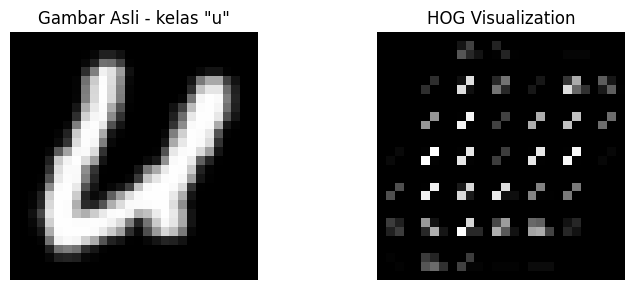

HOG feature vector length : 1296
Parameters -> orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)


In [8]:
# ── Parameter HOG (diubah dari default) ──────────────────────────────────────
ORIENTATIONS    = 9          # default=9
PIXELS_PER_CELL = (4, 4)     # default=(8,8) -> lebih detail
CELLS_PER_BLOCK = (2, 2)     # default=(3,3)

# Visualisasi HOG pada satu sampel
sample_img = X_train[0].reshape(28, 28).T

feat_sample, hog_img = hog(
    sample_img,
    orientations    = ORIENTATIONS,
    pixels_per_cell = PIXELS_PER_CELL,
    cells_per_block = CELLS_PER_BLOCK,
    visualize       = True,
    block_norm      = 'L2'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(sample_img, cmap='gray')
ax1.set_title(f'Gambar Asli - kelas "{chr(y_train[0]+97)}"')
ax1.axis('off')
ax2.imshow(hog_img, cmap='gray')
ax2.set_title('HOG Visualization')
ax2.axis('off')
plt.tight_layout()
plt.show()

print(f"HOG feature vector length : {feat_sample.shape[0]}")
print(f"Parameters -> orientations={ORIENTATIONS}, "
      f"pixels_per_cell={PIXELS_PER_CELL}, cells_per_block={CELLS_PER_BLOCK}")

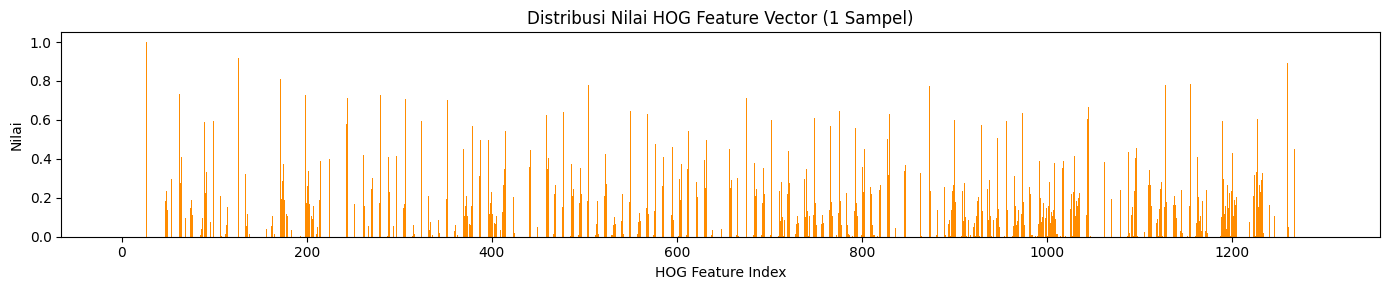

In [9]:
# ── Bar chart distribusi nilai HOG ────────────────────────────────────────────
plt.figure(figsize=(14, 3))
plt.bar(range(len(feat_sample)), feat_sample, color='darkorange', width=1)
plt.xlabel('HOG Feature Index')
plt.ylabel('Nilai')
plt.title('Distribusi Nilai HOG Feature Vector (1 Sampel)')
plt.tight_layout()
plt.show()

In [10]:
# ── Ekstraksi HOG untuk seluruh dataset ──────────────────────────────────────
def extract_hog_features(images, orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2)):
    features = []
    for img in images:
        f = hog(
            img.reshape(28, 28).T,
            orientations    = orientations,
            pixels_per_cell = pixels_per_cell,
            cells_per_block = cells_per_block,
            block_norm      = 'L2'
        )
        features.append(f)
    return np.array(features)

print("Mengekstrak fitur HOG dari training set...")
X_train_hog = extract_hog_features(X_train, ORIENTATIONS, PIXELS_PER_CELL, CELLS_PER_BLOCK)
print("Mengekstrak fitur HOG dari testing set...")
X_test_hog  = extract_hog_features(X_test,  ORIENTATIONS, PIXELS_PER_CELL, CELLS_PER_BLOCK)

print(f"\nX_train_hog shape : {X_train_hog.shape}")
print(f"X_test_hog  shape : {X_test_hog.shape}")

Mengekstrak fitur HOG dari training set...
Mengekstrak fitur HOG dari testing set...

X_train_hog shape : (2080, 1296)
X_test_hog  shape : (520, 1296)


---
## 3. Classification - SVM + Grid Search
Mencari kombinasi kernel, C, dan gamma terbaik menggunakan GridSearchCV.

In [11]:
# ── Definisi parameter grid ───────────────────────────────────────────────────
param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto']
}

svm = SVC(random_state=SEED)

grid_search = GridSearchCV(
    svm, param_grid,
    cv      = 3,
    n_jobs  = -1,
    verbose = 1,
    scoring = 'accuracy'
)

print("Memulai Grid Search (harap bersabar)...")
grid_search.fit(X_train_hog, y_train)

print("\n=== Hasil Grid Search ===")
print("Best Parameters :", grid_search.best_params_)
print("Best CV Score   :", round(grid_search.best_score_, 4))

Memulai Grid Search (harap bersabar)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== Hasil Grid Search ===
Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score   : 0.8


In [12]:
# ── Training performance dari model terbaik ───────────────────────────────────
best_model   = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train_hog)
train_acc    = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")

Training Accuracy : 1.0000 (100.00%)


---
## 4. Evaluation
Evaluasi pada **training set** (80%) dan **testing set** (20%) menggunakan accuracy, precision, recall, dan F1-score.

In [13]:
# ── Prediksi test set ─────────────────────────────────────────────────────────
y_test_pred = best_model.predict(X_test_hog)

# ── Fungsi ringkasan metrik ───────────────────────────────────────────────────
def print_metrics(y_true, y_pred, set_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*45}")
    print(f"  {set_name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

train_metrics = print_metrics(y_train, y_train_pred, "TRAINING SET (80%)")
test_metrics  = print_metrics(y_test,  y_test_pred,  "TESTING SET  (20%)")


  TRAINING SET (80%)
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

  TESTING SET  (20%)
  Accuracy  : 0.8212  (82.12%)
  Precision : 0.8294
  Recall    : 0.8212
  F1-Score  : 0.8217


In [14]:
# ── Classification Report (per kelas) ────────────────────────────────────────
label_names = [chr(i + 97) for i in range(26)]

print("\n=== Classification Report - Test Set ===")
print(classification_report(y_test, y_test_pred, target_names=label_names))


=== Classification Report - Test Set ===
              precision    recall  f1-score   support

           a       0.68      0.65      0.67        20
           b       0.80      0.80      0.80        20
           c       0.79      0.75      0.77        20
           d       0.89      0.80      0.84        20
           e       0.89      0.80      0.84        20
           f       0.88      0.75      0.81        20
           g       0.62      0.50      0.56        20
           h       0.86      0.95      0.90        20
           i       0.48      0.55      0.51        20
           j       0.89      0.85      0.87        20
           k       0.94      0.75      0.83        20
           l       0.61      0.70      0.65        20
           m       0.95      0.95      0.95        20
           n       0.76      0.95      0.84        20
           o       0.76      0.95      0.84        20
           p       0.95      0.95      0.95        20
           q       0.65      0.75      

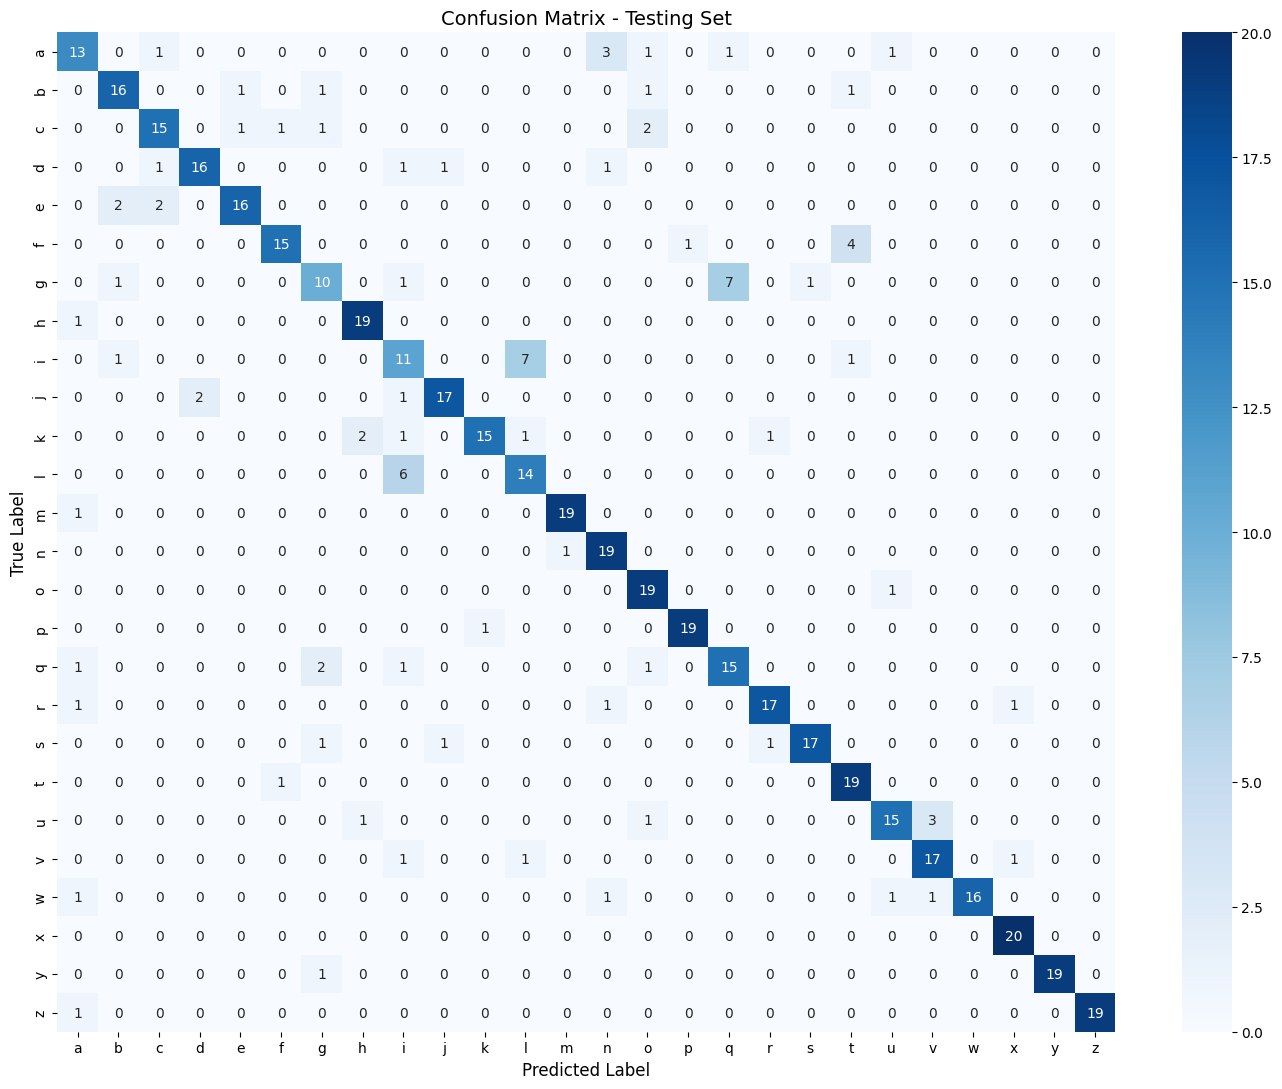

In [15]:
# ── Confusion Matrix - Test Set ───────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Testing Set', fontsize=14)
plt.tight_layout()
plt.show()

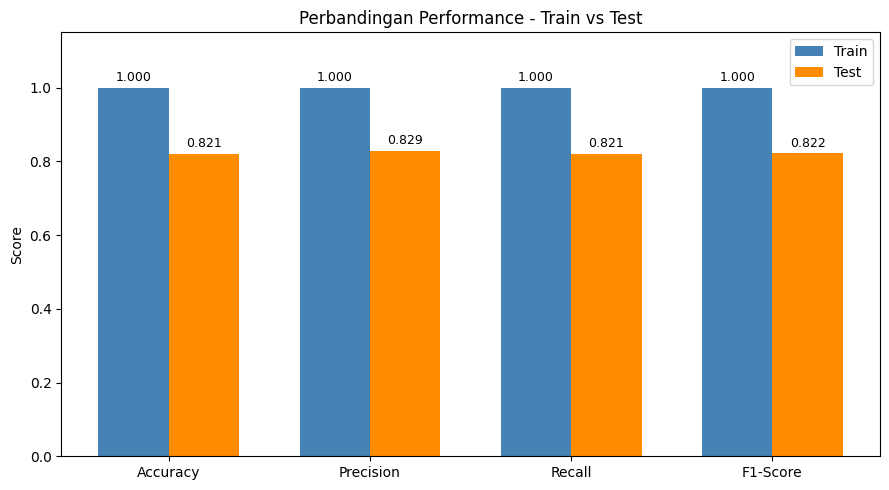

In [16]:
# ── Perbandingan Train vs Test Metrics (Bar Chart) ────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals   = list(train_metrics)
test_vals    = list(test_metrics)

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test',  color='darkorange')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performance - Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

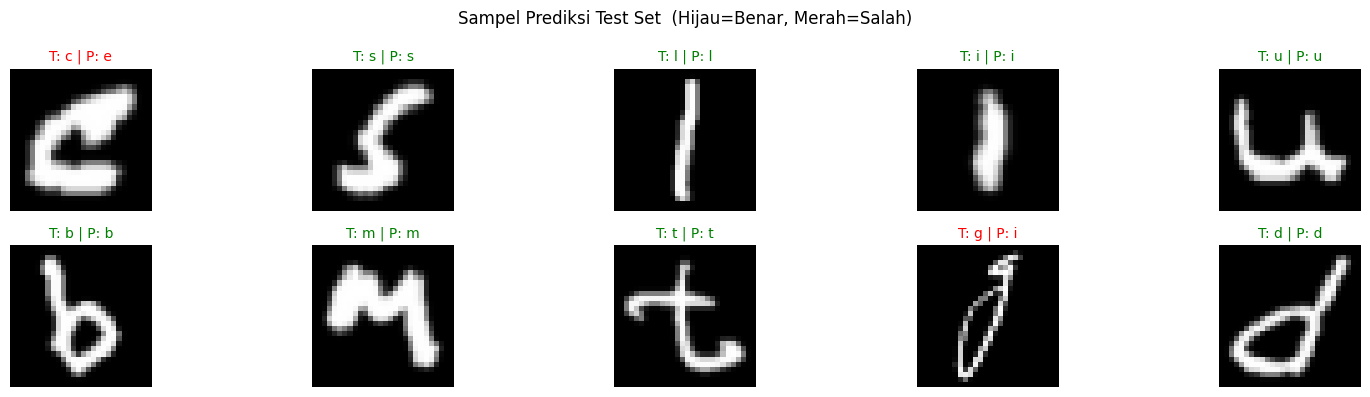


=== Ringkasan Final ===
Best SVM Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
HOG Parameters      : orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)
Train Accuracy      : 100.00%
Test  Accuracy      : 82.12%


In [18]:
# ── Visualisasi 10 Prediksi Acak dari Test Set ────────────────────────────────
indices = random.sample(range(len(X_test)), 10)

plt.figure(figsize=(16, 4))
for i, idx in enumerate(indices):
    img        = X_test[idx].reshape(28, 28).T
    true_label = chr(y_test[idx] + 97)
    pred_label = chr(y_test_pred[idx] + 97)
    color      = 'green' if true_label == pred_label else 'red'

    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {true_label} | P: {pred_label}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle("Sampel Prediksi Test Set  (Hijau=Benar, Merah=Salah)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Ringkasan Final ===")
print(f"Best SVM Parameters : {grid_search.best_params_}")
print(f"HOG Parameters      : orientations={ORIENTATIONS}, "
      f"pixels_per_cell={PIXELS_PER_CELL}, cells_per_block={CELLS_PER_BLOCK}")
print(f"Train Accuracy      : {train_metrics[0]*100:.2f}%")
print(f"Test  Accuracy      : {test_metrics[0]*100:.2f}%")